<h1 style="background:lightblue;color:darkblue;border-radius:5px;padding:30px;text-align:center;font-family:'Brush Script MT', cursive;font-size:40px">Life Goes On, Until the Iceberg Comes</h1>
    
    
 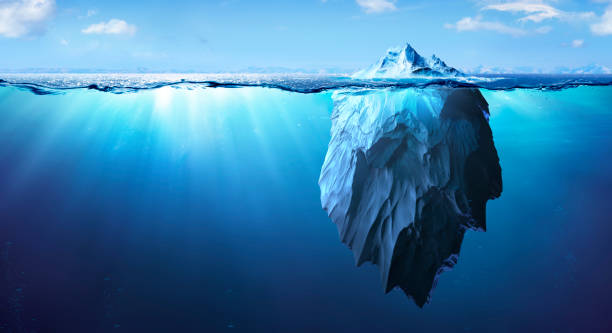

<ol>
    <li><a href="#visual">Data Visualization</a></li>
    <li><a href="#preparation">Preparing the Data for ML</a></li>
    <li><a href="#model">Machine Learning Model</a></li>
</ol>

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
train = pd.read_csv('/kaggle/input/titanic/train.csv')
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
test = pd.read_csv('/kaggle/input/titanic/test.csv')
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
train.drop(['PassengerId', 'Ticket', 'Name'], axis=1, inplace=True)
test.drop(['PassengerId', 'Ticket', 'Name'], axis=1, inplace=True)

<h1 id="visual" style="background:lightblue;color:darkblue;border-radius:5px;padding:30px;text-align:center;font-family:'Brush Script MT', cursive;font-size:40px">Data Visualization</h1>

In [5]:
plt.style.use('fivethirtyeight')

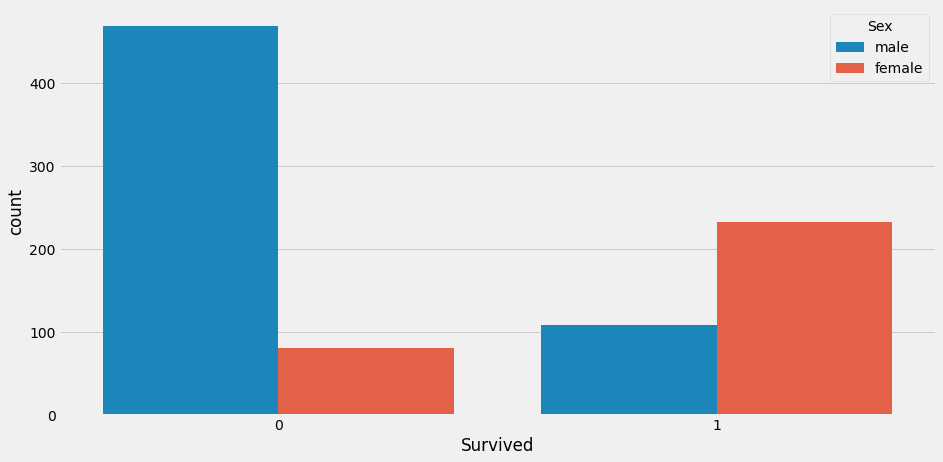

In [6]:
plt.figure(figsize=(14,7))

sns.countplot(data=train, x='Survived', hue='Sex')

plt.show()

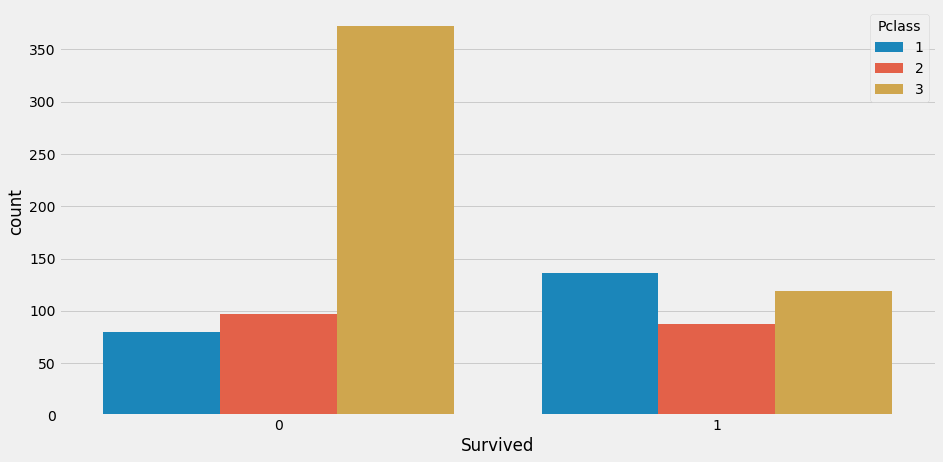

In [7]:
plt.figure(figsize=(14,7))

sns.countplot(data=train, x='Survived', hue='Pclass')

plt.show()

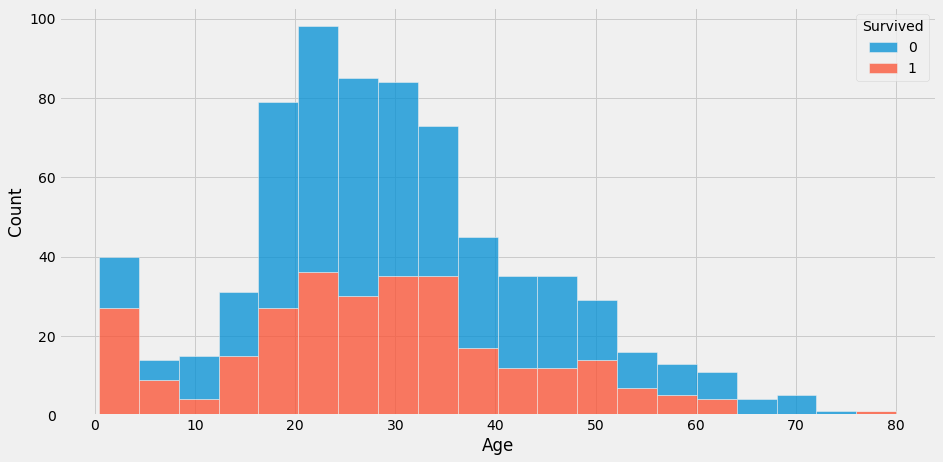

In [8]:
plt.figure(figsize=(14,7))
sns.histplot(data=train, x='Age', hue='Survived', multiple='stack')
plt.show()

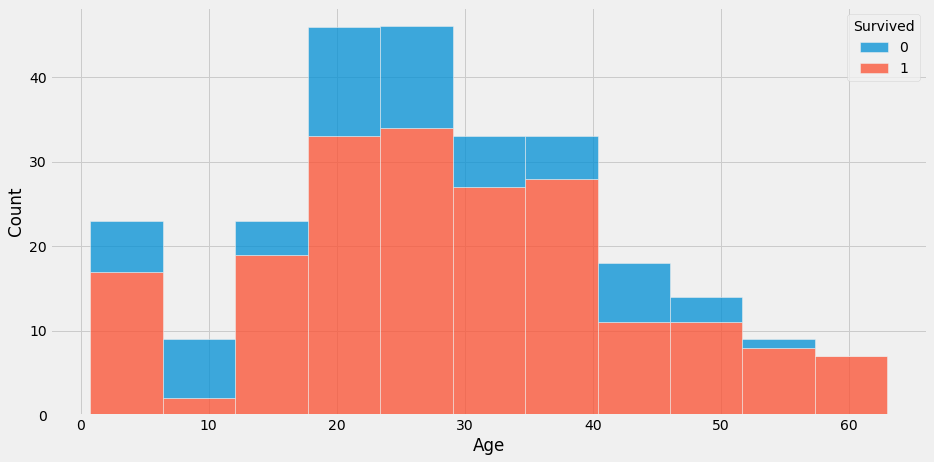

In [9]:
plt.figure(figsize=(14,7))
sns.histplot(data=train[train['Sex'] == 'female'], x='Age', hue='Survived', multiple='stack')
plt.show()

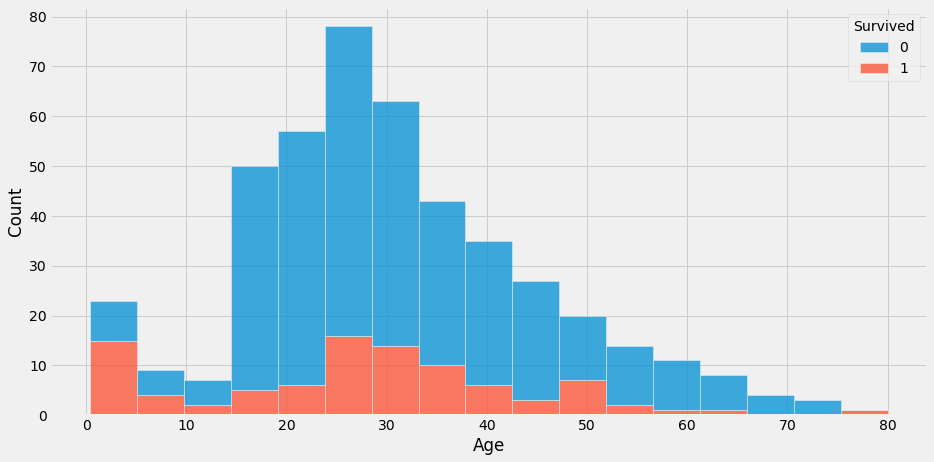

In [10]:
plt.figure(figsize=(14,7))
sns.histplot(data=train[train['Sex'] == 'male'], x='Age', hue='Survived', multiple='stack')
plt.show()

<h1 id="preparing" style="background:lightblue;color:darkblue;border-radius:5px;padding:30px;text-align:center;font-family:'Brush Script MT', cursive;font-size:40px">Preparing the Data for ML</h1>

Today, I am only going to keep the sex, pClass, and Age columns

In [11]:
train = train[['Sex', 'Pclass', 'Age', 'Survived']]
test = test[['Sex', 'Pclass', 'Age']]

In [12]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Sex       891 non-null    object 
 1   Pclass    891 non-null    int64  
 2   Age       714 non-null    float64
 3   Survived  891 non-null    int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 28.0+ KB


In [13]:
train['Age'].fillna(value=train.Age.mean(), inplace=True)

In [14]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Sex       891 non-null    object 
 1   Pclass    891 non-null    int64  
 2   Age       891 non-null    float64
 3   Survived  891 non-null    int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 28.0+ KB


In [15]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Sex     418 non-null    object 
 1   Pclass  418 non-null    int64  
 2   Age     332 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 9.9+ KB


In [16]:
test['Age'].fillna(value=test.Age.mean(), inplace=True)

The column 'Sex' is an object, we need to encode it as a binary column

In [17]:
gender_map = {'male': 0, 'female': 1}

train['Sex'] = train['Sex'].map(gender_map)
test['Sex'] = test['Sex'].map(gender_map)

In [18]:
test.head()

,Sex,Pclass,Age
0,0,3,34.5
1,1,3,47.0
2,0,2,62.0
3,0,3,27.0
4,1,3,22.0


<h1 id="model" style="background:lightblue;color:darkblue;border-radius:5px;padding:30px;text-align:center;font-family:'Brush Script MT', cursive;font-size:40px">Machine Learning Model</h1>

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [20]:
X_train = train[['Sex', 'Pclass', 'Age']].copy()
y_train = train['Survived'].copy()
X_test = test.copy()

In [21]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.3,
                                                 random_state=7) #Lucky number 7 ^^

In [22]:
model = RandomForestClassifier()
print('Training model...')
model.fit(X_train, y_train)
print('Model Trained Successfully! Predicting on Validation Split...')

y_pred = model.predict(X_val)
print('Prediction Done!')

Training model...
Model Trained Successfully! Predicting on Validation Split...
Prediction Done!


In [23]:
accuracy = accuracy_score(y_val, y_pred)
matrix = confusion_matrix(y_val, y_pred)
report = classification_report(y_val, y_pred)

In [24]:
print("The accuracy is: {:.3f}".format(accuracy))

The accuracy is: 0.806


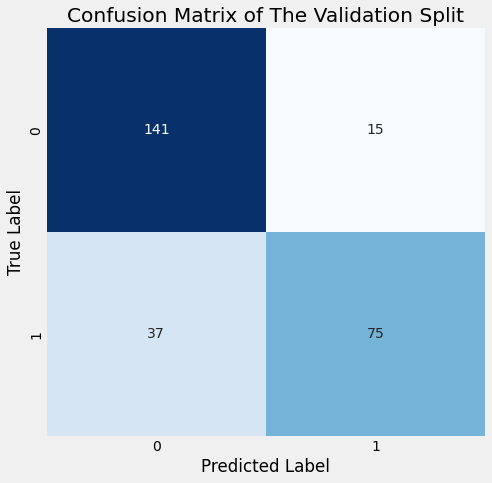

In [25]:
plt.figure(figsize=(7,7))
sns.heatmap(matrix, cbar=False, cmap='Blues', annot=True, fmt=".0f")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.title('Confusion Matrix of The Validation Split')
plt.show()

In [26]:
print(report)

              precision    recall  f1-score   support

           0       0.79      0.90      0.84       156
           1       0.83      0.67      0.74       112

    accuracy                           0.81       268
   macro avg       0.81      0.79      0.79       268
weighted avg       0.81      0.81      0.80       268



Nice Score! I will now try to predict the test split

In [27]:
final_pred = model.predict(X_test)

In [28]:
results = pd.read_csv('/kaggle/input/titanic/gender_submission.csv')
results.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [29]:
results['Survived'] = final_pred
results.to_csv('meeting_mr_iceberg.csv', index=False)

<h1 style="background:lightblue;color:darkblue;border-radius:5px;padding:30px;font-family: 'Brush Script MT', cursive">Thank you for reading my notebook, I would love to hear your feedback in the comment section</h1>